import pandas as pd


In [33]:
import pandas as pd
import matplotlib.pyplot as plt


In [6]:
orders = pd.read_excel('Data/Muesli Project raw data.xlsx', sheet_name='Orders')
campaign_data = pd.read_excel('Data/Muesli Project raw data.xlsx', sheet_name='Campaign Data')
order_process_data = pd.read_excel('Data/Muesli Project raw data.xlsx', sheet_name='Order Process Data')
intern_data_study = pd.read_excel('Data/Muesli Project raw data.xlsx', sheet_name='InternData Study')




In [10]:
# Check the 'Intern Data Study' File

intern_data_study.shape # 290 rows, 3 columns

(290, 3)

In [ ]:
# ready to ship and Pickup Date are datetime and Ordr Id is object
intern_data_study.dtypes

Order ID                      object
Ready to Ship Date    datetime64[ns]
Pickup Date           datetime64[ns]
dtype: object

In [11]:
intern_data_study.describe()

,Ready to Ship Date,Pickup Date
count,290,290
mean,2020-06-18 15:08:41.379310336,2020-06-20 06:47:10.344827648
min,2019-09-02 00:00:00,2019-09-03 00:00:00
25%,2019-09-23 00:00:00,2019-09-23 12:00:00
50%,2020-11-10 00:00:00,2020-11-12 00:00:00
75%,2020-11-23 00:00:00,2020-11-23 00:00:00
max,2020-12-07 00:00:00,2020-12-09 00:00:00


In [ ]:
# there are 86 duplicated rows in the dataset
# delete duplicates
intern_data_study.duplicated().sum()

np.int64(86)

In [ ]:
# there are 86 duplicated rows in Order ID
intern_data_study['Order ID'].duplicated().sum()

np.int64(86)

In [ ]:
# latest Pickup date in the dataset
max_date_pickup = intern_data_study['Pickup Date'].max()
max_date_pickup

Timestamp('2020-12-09 00:00:00')

In [ ]:
# earliest Pickup date in the dataset
min_date_pickup = intern_data_study['Pickup Date'].min()
min_date_pickup

Timestamp('2019-09-03 00:00:00')

In [ ]:
# 463 days timespan
time_differnce = max_date_pickup - min_date_pickup
time_differnce

Timedelta('463 days 00:00:00')

In [44]:
# calculate delivery time in days between ready to ship and pickup; make it more accurate and use hours?

intern_data_study['time_at_logistic_center'] = intern_data_study['Pickup Date'] - intern_data_study['Ready to Ship Date']
intern_data_study['time_at_logistic_center']

0     1 days
1     1 days
2     0 days
3     0 days
4     1 days
       ...  
285   3 days
286   3 days
287   3 days
288   3 days
289   2 days
Name: time_at_logistic_center, Length: 290, dtype: timedelta64[ns]

In [ ]:
# create updated dataset with delivery time column
intern_data_study.to_excel('updated_intern_data_study.xlsx', index=False)

In [ ]:
# how many orders per year
intern_data_study['Month-Year'] = intern_data_study['Pickup Date'].dt.to_period('M')
orders_per_month = intern_data_study.groupby('Month-Year')['Order ID'].count()
orders_per_month

Month-Year
2019-09     93
2019-10     10
2020-11    155
2020-12     32
Freq: M, Name: Order ID, dtype: int64

In [42]:
intern_data_study['Month-Year'].value_counts()

Month-Year
2020-11    155
2019-09     93
2020-12     32
2019-10     10
Freq: M, Name: count, dtype: int64

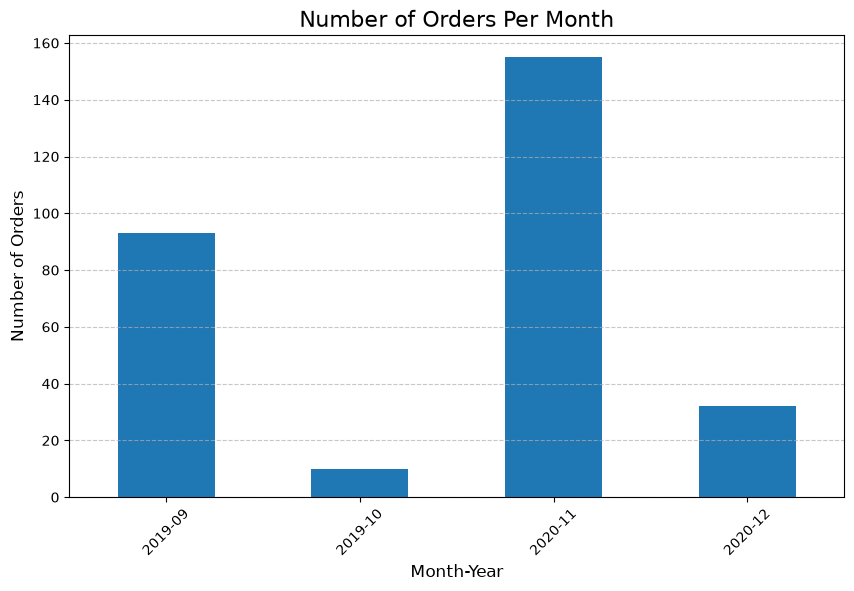

In [43]:
orders_per_month.plot(kind='bar', figsize=(10, 6))
plt.title('Number of Orders Per Month', fontsize=16)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)